In [ ]:
# import pandas as pd

# train_csv = "C:\\AIG_Sem2\\CapstoneProject\\Model_Training\\preprocessed\\train_preprocessed.csv"
# subset_csv = "C:\\AIG_Sem2\\CapstoneProject\\Model_Training\\preprocessed\\train_preprocessed_20pct.csv"

# df = pd.read_csv(train_csv)

# # random 20% sample
# df_subset = df.sample(frac=0.20, random_state=42).reset_index(drop=True)

# df_subset.to_csv(subset_csv, index=False)

# print("Original size:", len(df))
# print("Subset size:", len(df_subset))
# print("Saved to:", subset_csv)

Original size: 85440
Subset size: 17088
Saved to: C:\AIG_Sem2\CapstoneProject\Model_Training\preprocessed\train_preprocessed_20pct.csv


### Configuration

In [ ]:
# --- CONFIGURATION & HYPERPARAMETERS ---
CFG = {
    'model_name': 'CNN_LSTM_KLD_v2',
    'hidden_size': 128,
    'lr': 1e-3,
    'weight_decay': 1e-2,
    'epochs': 8,
    'batch_size': 8,

    # Use your preprocessed CSV files here
    'train_csv': "C:\\AIG_Sem2\\CapstoneProject\\Model_Training\\preprocessed\\train_preprocessed.csv",
    'val_csv': "C:\\AIG_Sem2\\CapstoneProject\\Model_Training\\preprocessed\\val_preprocessed.csv",
}

LABEL_COLS = [
    "seizure_vote",
    "lpd_vote",
    "gpd_vote",
    "lrda_vote",
    "grda_vote",
    "other_vote"
]

CLASS_NAMES = ['Seizure', 'LPD', 'GPD', 'LRDA', 'GRDA', 'Other']
print(f"Configuration Loaded. Model: {CFG['model_name']}, LR: {CFG['lr']}, Weight Decay: {CFG['weight_decay']}")

Configuration Loaded. Model: CNN_LSTM_KLD_v2, LR: 0.001, Weight Decay: 0.01


In [33]:
import torch
if torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    raise RuntimeError("No CUDA GPU detected. Please enable GPU or install CUDA-compatible runtime.")

print(f"Training on: {device}")

Training on: cuda:0


### Class counts and weights

In [34]:
import pandas as pd
import torch

train_csv = CFG['train_csv']  # your train_preprocessed.csv

df = pd.read_csv(train_csv)

label_cols = [
    "seizure_vote", "lpd_vote", "gpd_vote",
    "lrda_vote", "grda_vote", "other_vote"
]

# Sum votes per class
class_counts = df[label_cols].sum().values

print("Class counts:", class_counts)

# Inverse frequency (important)
class_weights = 1.0 / (class_counts + 1e-6)

# Normalize (optional but recommended)
class_weights = class_weights / class_weights.sum() * len(class_weights)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:", class_weights)

# Seizure: 0.7650
# LPD: 1.2261
# GPD: 1.2286
# LRDA: 1.1304
# GRDA: 0.9123
# Other: 0.7376
# Higher class counts get lower weights, and rarer classes get higher weights, which helps the model focus on underrepresented classes during training.

Class counts: [17804.45219408 11108.01684844 11085.50325274 12048.27822376
 14928.90360544 18464.8249991 ]
Class weights: tensor([0.7650, 1.2261, 1.2286, 1.1304, 0.9123, 0.7376], device='cuda:0')


### 1. Create PyTorch Dataset


In [36]:
import torch
from torch.utils.data import Dataset
import numpy as np
import pandas as pd

class SpectrogramDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)

        self.label_cols = [
            "seizure_vote", "lpd_vote", "gpd_vote",
            "lrda_vote", "grda_vote", "other_vote"
        ]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load preprocessed npy (spectrograms in shape (1,128,256))
        x = np.load(row["npy_path"])                        # shape (1,128,256)
        x = torch.tensor(x, dtype=torch.float32)

        # Load labels
        y = row[self.label_cols].values.astype(np.float32)   # shape: (6,)
        y = torch.tensor(y, dtype=torch.float32)

        return x, y

### 2. Create DataLoaders

In [37]:
from torch.utils.data import DataLoader

train_dataset = SpectrogramDataset("C:\\AIG_Sem2\\CapstoneProject\\Model_Training\\preprocessed\\train_preprocessed.csv")
val_dataset   = SpectrogramDataset("C:\\AIG_Sem2\\CapstoneProject\\Model_Training\\preprocessed\\val_preprocessed.csv")

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,       # Shuffling is important for training to ensure batches are different each epoch
    num_workers=0,      # Use multiple workers for faster data loading
    pin_memory=True     # Speeds up data transfer to GPU
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,       # No need to shuffle validation data
    num_workers=0,
    pin_memory=True
)

### Sanity check

In [5]:
x, y = train_dataset[0]
print("Single sample check:")
print("x shape:", x.shape)   # expected: [1, 128, 256]
print("y shape:", y.shape)   # expected: [6]
print("y sum:", y.sum())     # expected: ~1.0

# print("x_batch shape:", x_batch.shape)  # expected: [B, 1, 128, 256]
# print("y_batch shape:", y_batch.shape)  # expected: [B, 6]

Single sample check:
x shape: torch.Size([1, 128, 256])
y shape: torch.Size([6])
y sum: tensor(1.0000)


### Model Initialization

In [39]:
import torch
import torch.nn as nn
import timm

# model initialization
class HybridLSTMSpectrogramModel(nn.Module):
    def __init__(self, num_classes=6, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()

        # 1. The CNN Backbone (Same as Transformer version)
        self.cnn = timm.create_model(
            'efficientnet_b0',
            pretrained=True,
            in_chans=1,         # Our spectrograms have 1 channel
            features_only=True,
            out_indices=[4]     # Deepest block = 320 channels
        )

        cnn_out_channels = 320

        # 2. The LSTM Layer
        # Note: We don't need a projection layer here because we can just
        # tell the LSTM that the input_size is 320.
        self.lstm = nn.LSTM(
            input_size=cnn_out_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True, # Bidirectional helps it see past AND future
            dropout=dropout if num_layers > 1 else 0.0
        )

        # 3. Classifier
        # If bidirectional, the output size is hidden_size * 2
        #self.classifier = nn.Linear(hidden_size * 2, num_classes)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )


    def forward(self, x):
        # x shape: (Batch, 1, 128, 256)

        # 1. Extract Features via CNN
        features = self.cnn(x)[0] # Shape: (Batch, 320, H, W)

        # 2. Prepare for LSTM (Spatial -> Sequence)
        # Pool the Frequency (Height), leave Time (Width)
        features = features.mean(dim=2) # Shape: (Batch, 320, Time)

        # Permute to (Batch, Time, Features) for LSTM
        features = features.permute(0, 2, 1) # Shape: (Batch, Time, 320)

        # 3. LSTM Processing
        # output shape: (Batch, Time, hidden_size*2)
        # _ represents hidden states we don't need right now
        lstm_out, _ = self.lstm(features)

        # 4. Global Average Pooling
        # We take the average of all time steps to summarize the clip
        x = lstm_out.mean(dim=1)

        # 5. Classify
        output = self.classifier(x)
        return output

### Model / Optimizer / loss

In [ ]:
import torch.optim as optim

# model creation
model = HybridLSTMSpectrogramModel(
    num_classes=6,
    hidden_size=CFG['hidden_size'],
    dropout=0.3
)
model = model.to(device)

# Freeze CNN first
for param in model.cnn.parameters():
    param.requires_grad = False

# Then create optimizer
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG['lr'],
    weight_decay=CFG['weight_decay']
)

#loss_fn = nn.KLDivLoss(reduction='batchmean')
scaler = torch.amp.GradScaler('cuda')

def weighted_kl_loss(log_probs, targets, weights):
    loss = -targets * log_probs      # KL divergence part
    loss = loss * weights            # apply class weights
    return loss.sum(dim=1).mean()    # batchmean

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("\nModel, optimizer, and loss function loaded.")


Model, optimizer, and loss function loaded.


### Train/ Validate function

In [ ]:
from tqdm import tqdm
def train_one_epoch(dataloader, model, optimizer, device, class_weights):
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_samples = 0

    progress_bar = tqdm(dataloader, desc="Training", leave=False)

    for inputs, targets in progress_bar:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type='cuda'):
            outputs = model(inputs)
            log_probs = torch.nn.functional.log_softmax(outputs, dim=1)
            # loss = loss_fn(log_probs, targets)
            loss = weighted_kl_loss(log_probs, targets, class_weights)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        _, predicted = torch.max(outputs, 1)
        _, true_labels = torch.max(targets, 1)

        correct_preds += (predicted == true_labels).sum().item()
        total_samples += targets.size(0)

        running_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})
  

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct_preds / total_samples

    return epoch_loss, epoch_acc

def validate_one_epoch(dataloader, model, device, class_weights):
    model.eval()
    running_loss = 0.0
    correct_preds = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, targets in tqdm(dataloader, desc="Validating", leave=False):
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            with torch.autocast(device_type='cuda'):
                outputs = model(inputs)
                log_probs = torch.nn.functional.log_softmax(outputs, dim=1)
                # loss = loss_fn(log_probs, targets)
                loss = weighted_kl_loss(log_probs, targets, class_weights)

            _, predicted = torch.max(outputs, 1)
            _, true_labels = torch.max(targets, 1)

            correct_preds += (predicted == true_labels).sum().item()
            total_samples += targets.size(0)

            running_loss += loss.item()

    avg_loss = running_loss / len(dataloader)
    avg_acc = correct_preds / total_samples
    return avg_loss, avg_acc


### Training loop

In [ ]:
import time

best_val_loss = float('inf')
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

print(f"\nStarting training for {CFG['epochs']} epochs on {device}...")
start_time = time.time()

for epoch in range(CFG['epochs']):

    # Unfreeze CNN after 3 epochs for fine-tuning
    if epoch == 3:
        print("Unfreezing CNN for fine-tuning...")
        for param in model.cnn.parameters():
            param.requires_grad = True

        optimizer = optim.AdamW(
            model.parameters(),
            lr=1e-4,
            weight_decay=CFG['weight_decay']
        )


    train_loss, train_acc = train_one_epoch(train_loader, model, optimizer, device, class_weights)
    val_loss, val_acc = validate_one_epoch(val_loader, model, device, class_weights)

    if (epoch + 1) % 5 == 0:
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss
        }
        torch.save(checkpoint, f"{CFG['model_name']}_ckp{epoch + 1}.pth")

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(
        f"Epoch {epoch+1}/{CFG['epochs']} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CFG['model_name'] + '.pth')
        print(f"  --> New best model saved! (Val Loss: {val_loss:.4f})")

total_time = time.time() - start_time
print(f"\nTraining complete in {total_time/60:.2f} minutes!")


Starting training for 10 epochs on cuda:0...


Epoch 1/10 | Train Loss: 0.6452 | Train Acc: 0.6775 | Val Loss: 0.9360 | Val Acc: 0.6494
  --> New best model saved! (Val Loss: 0.9360)


Epoch 2/10 | Train Loss: 0.4469 | Train Acc: 0.7624 | Val Loss: 0.8888 | Val Acc: 0.6189
  --> New best model saved! (Val Loss: 0.8888)


Epoch 3/10 | Train Loss: 0.3846 | Train Acc: 0.7857 | Val Loss: 0.9012 | Val Acc: 0.6510


Epoch 4/10 | Train Loss: 0.3511 | Train Acc: 0.7985 | Val Loss: 0.9379 | Val Acc: 0.6073


...

Epoch 6/10 | Train Loss: 0.3114 | Train Acc: 0.8149 | Val Loss: 1.0051 | Val Acc: 0.5846


Epoch 7/10 | Train Loss: 0.2989 | Train Acc: 0.8220 | Val Loss: 0.9792 | Val Acc: 0.6392


Epoch 8/10 | Train Loss: 0.2903 | Train Acc: 0.8235 | Val Loss: 0.8647 | Val Acc: 0.6324
  --> New best model saved! (Val Loss: 0.8647)


Epoch 9/10 | Train Loss: 0.2804 | Train Acc: 0.8298 | Val Loss: 1.0240 | Val Acc: 0.5436


Epoch 10/10 | Train Loss: 0.2719 | Train Acc: 0.8333 | Val Loss: 1.0905 | Val Acc: 0.5734

Training complete in 66.42 minutes!


In [12]:
# Save the best model
model.load_state_dict(torch.load(CFG['model_name'] + '.pth'))
model.eval()
print("\nBest model loaded for evaluation.")


Best model loaded for evaluation.


In [16]:
#Plots
import matplotlib.pyplot as plt
def plot_history(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history['train_loss'], label='Train Loss', lw=2, marker='o')
    plt.plot(history['val_loss'], label='Val Loss', lw=2, marker='o')

    plt.title('Training and Validation Loss (KL Divergence): ' + CFG['model_name'])
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    best_epoch = np.argmin(history['val_loss'])
    plt.annotate(
        f'Best: {history["val_loss"][best_epoch]:.4f}',
        xy=(best_epoch, history['val_loss'][best_epoch]),
        xytext=(best_epoch, history['val_loss'][best_epoch] + 0.1),
        arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5)
    )
    plt.show()

def plot_accuracy(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history['train_acc'], label='Train Accuracy', lw=2, marker='s')
    plt.plot(history['val_acc'], label='Val Accuracy', lw=2, marker='s')

    plt.title('Model Accuracy (Top-1)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()


### Evaluation Helpers

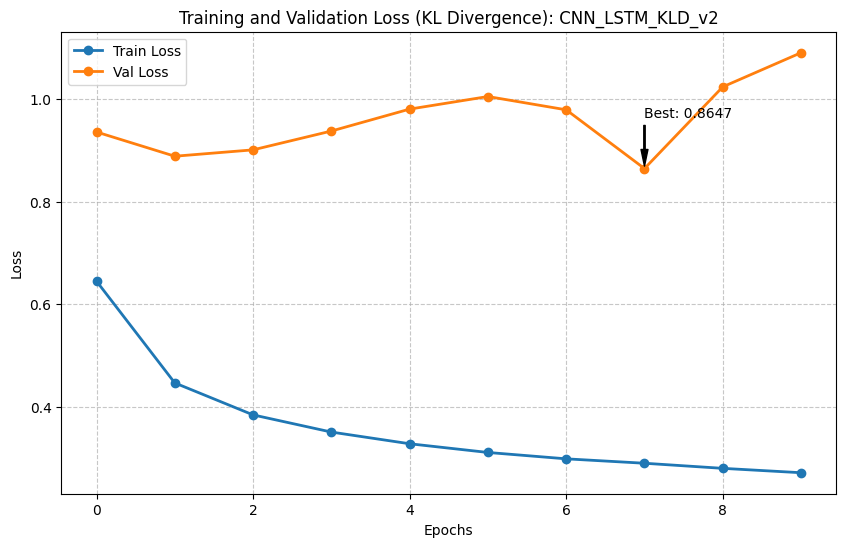

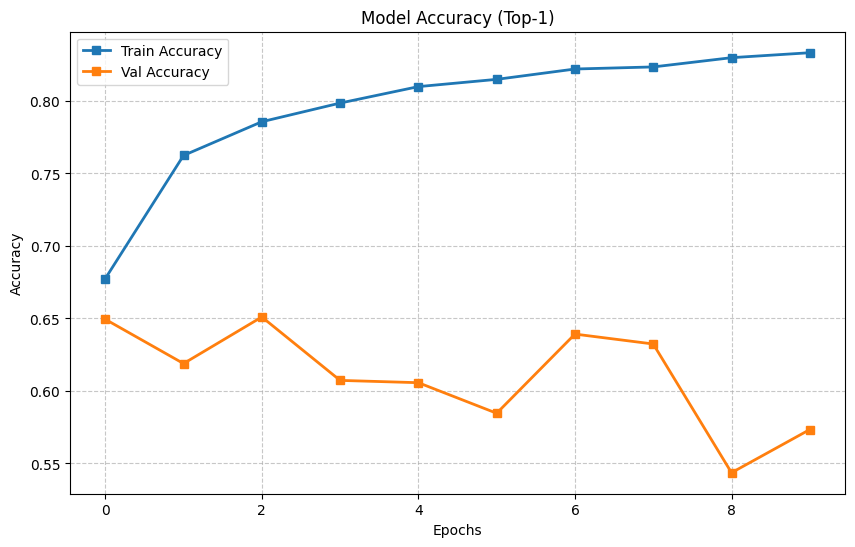

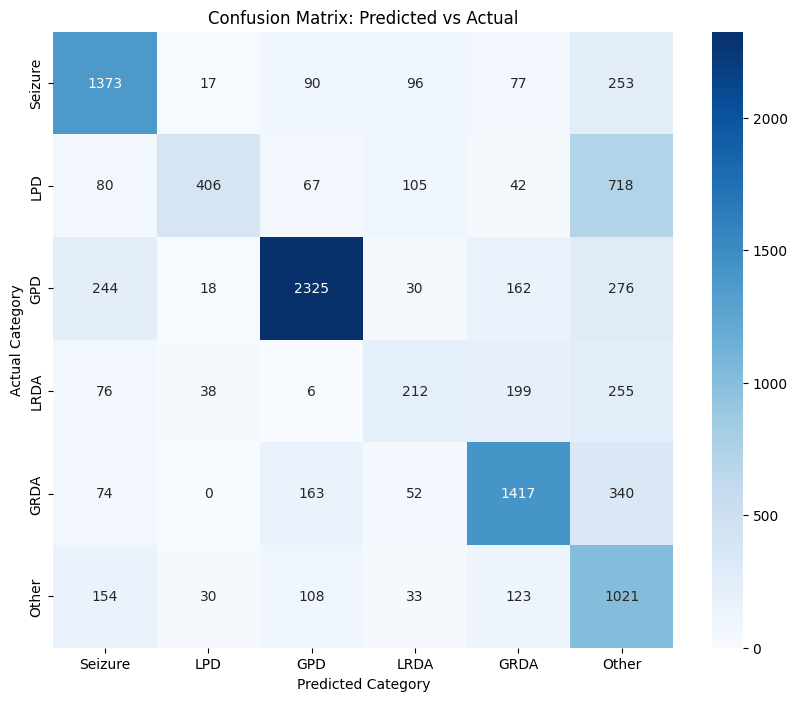


--- Comparison Report ---
Top-1 Accuracy: 0.6324
Macro F1-Score: 0.5692


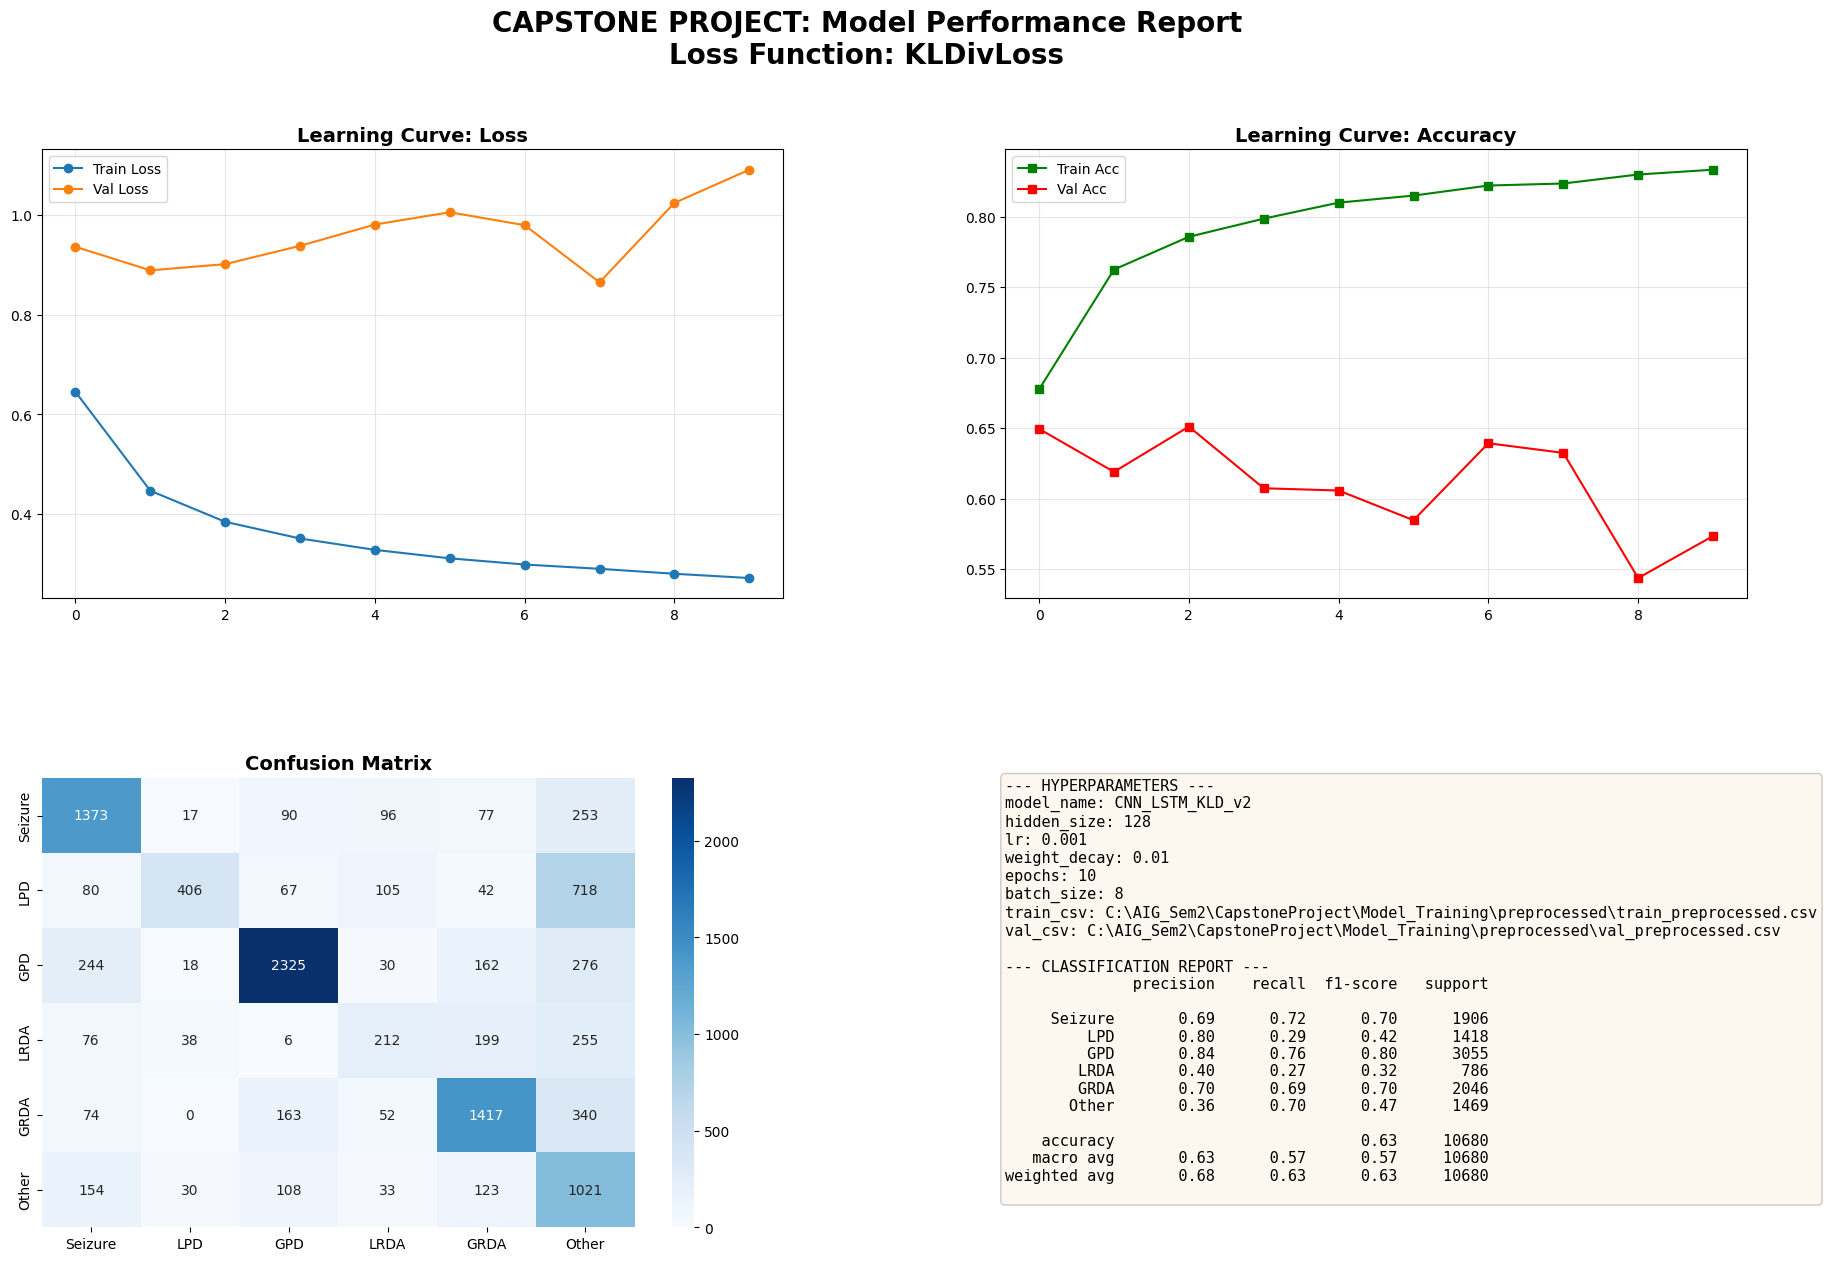


Saved final report to: KL_report_CNN_LSTM_KLD_v2.png


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import seaborn as sns

def get_predictions(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            outputs = model(inputs)

            _, preds = torch.max(outputs, 1)
            _, labels = torch.max(targets, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

def plot_confusion_matrix(model, dataloader, device):
    all_preds, all_labels = get_predictions(model, dataloader, device)
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.title('Confusion Matrix: Predicted vs Actual')
    plt.ylabel('Actual Category')
    plt.xlabel('Predicted Category')
    plt.show()

def calculate_comparative_metrics(model, dataloader, device):
    all_preds, all_labels = get_predictions(model, dataloader, device)

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    print("\n--- Comparison Report ---")
    print(f"Top-1 Accuracy: {acc:.4f}")
    print(f"Macro F1-Score: {f1:.4f}")

    return acc, f1

def generate_final_report(model, dataloader, history, device, filename=None):
    all_preds, all_labels = get_predictions(model, dataloader, device)

    if filename is None:
        filename = f"KL_report_{CFG['model_name']}.png"

    fig = plt.figure(figsize=(22, 14), facecolor='white')
    grid = plt.GridSpec(2, 2, wspace=0.3, hspace=0.4)

    ax1 = fig.add_subplot(grid[0, 0])
    ax1.plot(history['train_loss'], label='Train Loss', marker='o')
    ax1.plot(history['val_loss'], label='Val Loss', marker='o')
    ax1.set_title('Learning Curve: Loss', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2 = fig.add_subplot(grid[0, 1])
    ax2.plot(history['train_acc'], label='Train Acc', color='green', marker='s')
    ax2.plot(history['val_acc'], label='Val Acc', color='red', marker='s')
    ax2.set_title('Learning Curve: Accuracy', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    ax3 = fig.add_subplot(grid[1, 0])
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax3
    )
    ax3.set_title('Confusion Matrix', fontsize=14, fontweight='bold')

    ax4 = fig.add_subplot(grid[1, 1])
    ax4.axis('off')

    cfg_display = {k: v for k, v in CFG.items() if 'path' not in k and 'dir' not in k}
    cfg_text = "\n".join([f"{k}: {v}" for k, v in cfg_display.items()])

    report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES)

    full_text = f"--- HYPERPARAMETERS ---\n{cfg_text}\n\n"
    full_text += f"--- CLASSIFICATION REPORT ---\n{report}"

    ax4.text(
        0, 1, full_text,
        family='monospace',
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.2)
    )

    plt.suptitle(
        f"CAPSTONE PROJECT: Model Performance Report\nLoss Function: Weighted KL Divergence (Class-Imbalance Aware)",
        fontsize=20,
        fontweight='bold',
        y=0.98
    )

    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nSaved final report to: {filename}")

# =========================================================
# RUN EVALUATION
# =========================================================
plot_history(history)
plot_accuracy(history)
plot_confusion_matrix(model, val_loader, device)
calculate_comparative_metrics(model, val_loader, device)
generate_final_report(model, val_loader, history, device)